In [1]:
# ====================================================================
# 0. imports & reproducibility
# ====================================================================
import pandas as pd, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tcn import TCN
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
from pathlib import Path

rng = np.random.default_rng(42)
tf.keras.utils.set_random_seed(42)
tf.debugging.enable_check_numerics()          # crash early on NaN/Inf

INFO:tensorflow:Enabled check-numerics callback in thread MainThread


In [2]:
# ------------------------------------------------------------------
# files you want to merge  (add as many as you like)
# ------------------------------------------------------------------
FILES = [
    "previous_dv0_withoutstraw_sipCAdded.xlsx", 
    "dv0_withoutstraw_sipCAdded.xlsx",
                       # ← put your second file name here
    # "third_file.xlsx",
]

In [3]:
# ------------------------------------------------------------------
# read & re-index
# ------------------------------------------------------------------
dfs          = []
next_offset  = 0          # keeps track of the next free Participant_ID

for fp in FILES:
    fp = Path(fp)
    df = pd.read_excel(fp)

    # current file's min/max before shifting (optional print for sanity)
    old_min, old_max = df["Participant_ID"].min(), df["Participant_ID"].max()
    print(f"{fp.name}: original IDs {old_min} … {old_max}")

    # shift IDs so they don't collide with previous files
    df["Participant_ID"] += next_offset

    # update next_offset for the *next* file
    next_offset = df["Participant_ID"].max() + 1

    # done
    dfs.append(df)
    print(f"   shifted to {df['Participant_ID'].min()} … {df['Participant_ID'].max()}")


previous_dv0_withoutstraw_sipCAdded.xlsx: original IDs 6 … 62
   shifted to 6 … 62
dv0_withoutstraw_sipCAdded.xlsx: original IDs 1 … 14
   shifted to 64 … 77


In [4]:
# ------------------------------------------------------------------
# combined DataFrame
# ------------------------------------------------------------------
df_all = pd.concat(dfs, ignore_index=True)
print("\nMerged dataframe shape:", df_all.shape)
print("Global Participant_ID range:", df_all["Participant_ID"].min(),
      "…", df_all["Participant_ID"].max())


Merged dataframe shape: (99996, 82)
Global Participant_ID range: 6 … 77


In [5]:
df = df_all

In [6]:
# print("Label stats  (raw, before scaling)")
# print("  min :", y.min())
# print("  #zeros :", (y == 0).sum())
# print("  any negative? ", (y < 0).any())

In [7]:

# --------------------------------------------------------------------
# user settings
# --------------------------------------------------------------------

BATCH      = 32                                   # 1 = ragged, >1 = padded


In [8]:
# ====================================================================
# 1. load data  ➜  X(list of (T,64)), y(array)   – SKIP zero-volume sips
# ====================================================================
df = df[df["Label"] == 1]                        # keep only annotated frames

feature_cols = df.columns[1:65]
seq_keys, label_col = ["Participant_ID", "sip_id"], "dV"

X, y = [], []
skip_count = 0

for _, g in df.groupby(seq_keys, sort=False):
    dV = float(g[label_col].iloc[0])
    if dV == 0.0:                                # ← drop empty sip
        skip_count += 1
        continue
    X.append(g[feature_cols].to_numpy(np.float32))   # (T,64)
    y.append(dV)

y = np.asarray(y, np.float32)
X = np.array(X, dtype=object)   # each element is still a (T,64) array
print(f"Total sips kept : {len(X)}")
print(f"Zero-volume skipped : {skip_count}")
print("Label stats  → min:", y.min(), "max:", y.max())

Total sips kept : 383
Zero-volume skipped : 2
Label stats  → min: 1.4691479 max: 160.2


In [9]:
# ====================================================================
# 2. shuffle whole sips ➜ 80 / 20 split
# ====================================================================
idx = rng.permutation(len(X))
split1 = int(.64 * len(X))          # 64 % train
split2 = int(.80 * len(X))          # next 16 % val
X_train, y_train = X[idx[:split1]], y[idx[:split1]]
X_val,   y_val   = X[idx[split1:split2]], y[idx[split1:split2]]
X_test,  y_test  = X[idx[split2:]], y[idx[split2:]]
print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")
# y_train_s = np.log1p(y_train)        # log1p for numerical safety
# y_val_s   = np.log1p(y_val)
# y_test_s  = np.log1p(y_test)


Train 245 Val 61  Test 77


In [10]:
# X_train


In [11]:
y_train

array([ 59.52381  ,  80.7      ,  27.238094 ,  26.984127 ,  39.177277 ,
        58.7      ,  59.52381  ,  39.68254  ,  46.5      ,  18.511263 ,
        12.747036 ,  38.095238 ,  38.190475 ,  19.84127  ,  78.35455  ,
        26.09127  ,  10.479921 ,  20.       ,  44.7      ,  12.5      ,
        80.       ,  27.815866 ,  61.904762 ,   6.072478 ,  29.1      ,
        13.1      ,  19.047619 ,   7.7832513,  38.1      ,  69.90476  ,
       131.7      ,  42.9      ,  10.773751 ,  69.73555  ,  59.7      ,
        10.246305 ,  39.68254  ,  14.201763 ,  60.       ,  25.099207 ,
        15.083252 ,  54.3      ,  19.196865 ,  34.7      ,   9.064039 ,
         6.502463 ,  39.1      ,  30.095238 ,  39.68254  ,  97.94319  ,
        36.3      ,  40.47619  ,  19.588638 ,  40.       ,   8.952381 ,
        14.624506 ,  42.190475 ,  40.       ,   5.582762 ,  28.403526 ,
         2.9382958,  32.223312 ,   8.227228 ,  14.130435 ,   9.55665  ,
        11.5079365,   6.206897 ,  40.       ,  40.       ,  60.8

In [12]:
# ====================================================================
# 3. column-wise z-score normalisation (fit on training only)
# ====================================================================
mat_train = np.vstack(X_train)          # ⬅ only TRAIN data
mean64 = mat_train.mean(0, keepdims=True)
std64  = mat_train.std(0,  keepdims=True) + 1e-8

norm = lambda seq: (seq - mean64) / std64
X_train = [norm(s) for s in X_train]
X_val   = [norm(s) for s in X_val]
X_test  = [norm(s) for s in X_test]

# # label scaling
# y_max   = y_train.max() or 1.
# y_train_s = y_train / y_max
# y_val_s   = y_val   / y_max
# y_test_s  = y_test  / y_max
y_train_s = y_train 
y_val_s   = y_val   
y_test_s  = y_test  

print(np.round(y_train_s[:5], 3)) # should be about [4.106, 4.407, 3.311, …]

[59.524 80.7   27.238 26.984 39.177]


In [13]:
# ====================================================================
# 4. tf.data pipelines
# ====================================================================
def generator(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),
    tf.TensorSpec((),          tf.float32)
)

def make_ds(xs, ys, shuffle=True):
    ds = tf.data.Dataset.from_generator(lambda: generator(xs, ys),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if BATCH == 1:
        return ds.repeat().batch(1)              # ragged
    return ds.repeat().padded_batch(             # padded
        BATCH,
        padded_shapes=([None, 64], []),
        padding_values=(0.0, 0.0)
    )

train_ds = make_ds(X_train, y_train_s, shuffle=True)
val_ds   = make_ds(X_val,   y_val_s,   shuffle=False)
test_ds  = make_ds(X_test,  y_test_s,  shuffle=False)

In [14]:
# ====================================================================
# 5. model  – TCN ➜ Dense(1, softplus) keeps output ≥ 0
# ====================================================================
inp = tf.keras.Input(shape=(None, 64))
x = TCN(nb_filters=128,
        kernel_size=3,
        dilations=[1,2,4,8,16,32],   # ~64-time-step field
        dropout_rate=0.1,
        return_sequences=False)(inp)
out = tf.keras.layers.Dense(1)(x)          # ← LINEAR output
model = tf.keras.Model(inp, out)

model.compile(
    tf.keras.optimizers.Adam(1e-3),        # a bit faster
    loss="mae"                             # MAE is more robust
)
model.summary()

steps_per_epoch = len(X_train) // BATCH + (len(X_train) % BATCH > 0)
val_steps       = len(X_val)   // BATCH + (len(X_val)   % BATCH > 0)
# weights = (y_train / y_train.max()) ** 0.5  
cb = tf.keras.callbacks.EarlyStopping(
         monitor='val_loss', patience=10, restore_best_weights=True)
model.fit(
    train_ds,
    epochs=100,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,        # ⬅ use VALIDATION set
    validation_steps=val_steps,
    verbose=1,
    # sample_weight=weights,
    callbacks=[cb]
)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn (TCN)                       │ (None, 128)            │       575,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,233 (2.19 MB)

 Trainable params: 575,233 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 25.0549 - val_loss: 20.9680
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 17.8003 - val_loss: 18.1018
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 17.3680 - val_loss: 16.8265
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 15.2827 - val_loss: 18.2020
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 15.5345 - val_loss: 15.4291
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 13.7934 - val_loss: 16.1743
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 12.4773 - val_loss: 14.8017
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 12.6992 - val_loss: 15.1139
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 10.0282 - val_loss: 15.7407
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 11.9851 - val_loss: 14.9497
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 11.7624 - val_loss: 14.2889
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step -

In [15]:
# ====================================================================
# 6. inference on test set (un-scale predictions)
# ====================================================================
y_pred_s = np.array([model.predict(seq[None, ...], verbose=0)[0, 0]
                     for seq in X_test])
# inverse transform after prediction
# y_pred_s = np.expm1(y_pred_s)
# y_pred   = y_pred_s * y_max
y_pred = y_pred_s
y_mean, y_std = y_train.mean(), y_train.std()
y_train_s = (y_train - y_mean) / y_std
# ...
# y_pred = y_pred_s * y_std + y_mean       # undo scaling

In [16]:
# ====================================================================
# 7. evaluation
# ====================================================================
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

non_zero = y_test != 0
rmspe = (np.sqrt(np.mean(((y_test[non_zero]-y_pred[non_zero]) /
                          y_test[non_zero])**2))*100
         if non_zero.any() else np.nan)

print(f"\nEvaluation on {len(y_test)} test sips")
print(f"  MSE   : {mse:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  R²    : {r2:.4f}")
print(f"  RMSPE : {rmspe:.2f}%")

comparison_df = pd.DataFrame({"Actual dV": y_test, "Predicted dV": y_pred})
print("\nFirst 50 predictions:")
print(comparison_df.head(50))


Evaluation on 77 test sips
  MSE   : 352.7251
  RMSE  : 18.7810
  R²    : 0.4583
  RMSPE : 92.47%

First 50 predictions:
     Actual dV  Predicted dV
0   103.800003     59.002567
1    40.095238     11.032620
2     8.275862      5.583666
3    58.765915     50.589924
4    11.655240      7.818164
5     9.809524     33.928017
6    11.111111     18.143820
7    12.536729     17.733702
8    76.190475     32.231686
9    25.465231     24.517498
10   15.513834     38.995701
11    9.162561      3.900505
12   58.000000     56.509155
13   20.470127     16.122677
14   13.712047      8.455052
15   10.476191     21.344658
16   41.523811     18.430384
17   25.799999     16.370455
18   35.200001     17.244732
19   16.380953     19.121988
20  100.000000     60.819321
21   16.400000     18.861992
22    6.660137     21.662344
23   57.142857     23.643240
24   12.996032     39.177612
25   85.699997     58.372459
26   79.365082     70.531334
27   60.000000     40.928337
28   27.182539     10.861214
29   24.

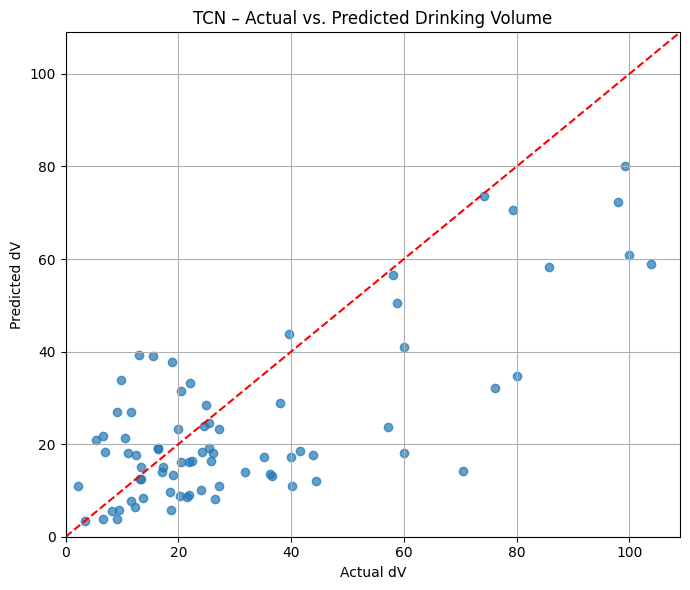

In [17]:
# ====================================================================
# 8. scatter plot
# ====================================================================
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
lims = [0, max(y_test.max(), y_pred.max()) * 1.05]
plt.plot(lims, lims, "r--")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual dV"); plt.ylabel("Predicted dV")
plt.title("TCN – Actual vs. Predicted Drinking Volume")
plt.grid(True); plt.tight_layout(); plt.show()

In [18]:
# print("First 5 log targets  :", y_train_s[:5])
# print("First 5 raw targets  :", y_train[:5])

# # after one epoch
# raw_pred = np.expm1(model.predict(X_val[:3])[...,0])
# print("First 3 un-scaled predictions:", raw_pred)

In [19]:
print("train  min / max (ml):", y_train.min(), y_train.max())
print("train_s min / max (log):", y_train_s.min(), y_train_s.max())

# quick expectation check:  ln(1+160) ≈ 5.08
#                           ln(1+  5) ≈ 1.79

train  min / max (ml): 1.4691479 160.2
train_s min / max (log): -1.271691 4.6831155


In [20]:
# ─── 1. define & compile the model ──────────────────────────
model = build_tcn()                  # your smaller-TCN function
model.compile(Adam(3e-4), loss=Huber())

# ─── 2. build tf.data datasets  (they use log targets) ─────
train_ds = make_ds(X_train, y_train_s, shuffle=True)
val_ds   = make_ds(X_val,   y_val_s,   shuffle=False)

# ─── 3. fit ────────────────────────────────────────────────
model.fit(train_ds, ...)

# ─── 4. evaluate ───────────────────────────────────────────
y_pred_log = model.predict(test_ds).squeeze()
y_pred_ml  = np.expm1(y_pred_log)

NameError: name 'build_tcn' is not defined

In [ ]:

# ------------------------------------------------------------
# 0.  Imports
# ------------------------------------------------------------
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import LogCosh
from tensorflow.keras.callbacks import EarlyStopping
from tcn import TCN                               # pip install keras-tcn

# ------------------------------------------------------------
# 1.  LOAD YOUR DATA  ----------------------------------------
#     Replace the three “TODO” blocks by real arrays / lists.
#     • X_* : iterable of float32 arrays with shape (T_i, 64)
#     • y_* : 1-D float32 array of drink volumes in millilitres
# ------------------------------------------------------------
# TODO ------------------------------------------------------------------
# X_train, X_val, X_test = [...]
# y_train, y_val, y_test = [...]
# -----------------------------------------------------------------------
assert len(X_train) == len(y_train)

# ------------------------------------------------------------
# 2.  LOG-TRANSFORM LABELS  (no further scaling!)
# ------------------------------------------------------------
y_train_s = np.log1p(y_train)
y_val_s   = np.log1p(y_val)
y_test_s  = np.log1p(y_test)

print("check min/max log targets:", y_train_s.min(), y_train_s.max())
# should be roughly 0.9 … 5.1 and never negative

# ------------------------------------------------------------
# 3.  Build tf.data pipelines
#       • Training set repeats (for steps_per_epoch)
#       • Validation / Test do NOT repeat
#       • All three use padding to batch variable-length sequences
# ------------------------------------------------------------
BATCH = 32

def gen(xs, ys, ws):
    for x, y, w in zip(xs, ys, ws):
        yield x, y, w

output_sig = (
    tf.TensorSpec((None, 64), tf.float32),  # sequence
    tf.TensorSpec((),          tf.float32),  # label
    tf.TensorSpec((),          tf.float32)   # weight
)

# simple sample-weight: sqrt(volume/max)
w_train = np.power(y_train / y_train.max(), 0.5).astype(np.float32)
w_val   = np.ones_like(y_val,  np.float32)
w_test  = np.ones_like(y_test, np.float32)

def make_ds(xs, ys, ws, shuffle, repeat=False):
    ds = tf.data.Dataset.from_generator(lambda: gen(xs, ys, ws),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if repeat:
        ds = ds.repeat()
    return (ds
            .padded_batch(BATCH,
                          padded_shapes=([None, 64], [], []),
                          padding_values=(0.0, 0.0, 1.0))
            .prefetch(tf.data.AUTOTUNE))

train_ds = make_ds(X_train, y_train_s, w_train, shuffle=True,  repeat=True)
val_ds   = make_ds(X_val,   y_val_s,   w_val,   shuffle=False, repeat=False)
test_ds  = make_ds(X_test,  y_test_s,  w_test,  shuffle=False, repeat=False)

STEPS_PER_EPOCH = 32                           # 32×32 ≈ 1 k sequences / epoch
VAL_STEPS       = len(X_val) // BATCH + 1

# ------------------------------------------------------------
# 4.  Model definition: smaller TCN + dense head
# ------------------------------------------------------------
def build_tcn():
    inp = tf.keras.Input(shape=(None, 64))
    x = TCN(nb_filters=64,
            kernel_size=3,
            dilations=[1, 2, 4, 8, 16, 32],
            dropout_rate=0.15,
            return_sequences=False)(inp)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.10)(x)
    out = tf.keras.layers.Dense(1)(x)          # linear
    return tf.keras.Model(inp, out)

model = build_tcn()
model.compile(optimizer=Adam(3e-4), loss=LogCosh())
model.summary()

# ------------------------------------------------------------
# 5.  Training
# ------------------------------------------------------------
early = EarlyStopping('val_loss', patience=30, restore_best_weights=True)

history = model.fit(train_ds,
                    epochs=200,
                    steps_per_epoch=STEPS_PER_EPOCH,
                    validation_data=val_ds,
                    validation_steps=VAL_STEPS,
                    callbacks=[early],
                    verbose=1)

# ------------------------------------------------------------
# 6.  Evaluation
# ------------------------------------------------------------
# log-space predictions
y_pred_log = np.concatenate([model.predict(b[0], verbose=0) for b in test_ds])[:, 0]
y_pred     = np.expm1(y_pred_log)               # back to millilitres

mse  = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)
r2   = 1 - np.sum((y_test - y_pred) ** 2) / np.sum((y_test - y_test.mean()) ** 2)

print(f"\nTest RMSE: {rmse:.2f} ml   |   R²: {r2:.3f}")

# scatter plot
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([0, 160], [0, 160], c='r')
plt.xlabel('Actual (ml)'); plt.ylabel('Predicted (ml)')
plt.xlim(0, 160); plt.ylim(0, 160); plt.grid(True)
plt.show()

# first 20 pairs
print("\nFirst 20 predictions:")
for a, p in zip(y_test[:20], y_pred[:20]):
    print(f"actual {a:7.1f} ml  →  pred {p:7.1f} ml")


In [ ]:

"""
End-to-end script – copy into a .py file or a Jupyter cell and run.

Major changes vs. previous draft
1.  NO sample–weights  → the model cares about large gulps again.
2.  Loss switched to Huber(δ=1.0) in log-space.
3.  Larger TCN (128 filters, 7 dilation levels) + 128-unit dense head.
4.  More optimisation steps per epoch (STEPS_PER_EPOCH = 256).
5.  Added sanity prints: log-targets, sample log→ml conversion, layer count.
"""

# ------------------------------------------------------------
# 0.  Imports
# ------------------------------------------------------------
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping
from tcn import TCN                               # pip install keras-tcn

# ------------------------------------------------------------
# 1.  LOAD YOUR DATA
#     Replace the three TODO blocks with real arrays / lists
# ------------------------------------------------------------
# TODO: -------------------------------------------------------
# X_train, X_val, X_test = [...]
# y_train, y_val, y_test = [...]
idx = rng.permutation(len(X))
split1 = int(.64 * len(X))          # 64 % train
split2 = int(.80 * len(X))          # next 16 % val
X_train, y_train = X[idx[:split1]], y[idx[:split1]]
X_val,   y_val   = X[idx[split1:split2]], y[idx[split1:split2]]
X_test,  y_test  = X[idx[split2:]], y[idx[split2:]]
print(f"Train {len(X_train)} Val {len(X_val)}  Test {len(X_test)}")
# -------------------------------------------------------------
assert len(X_train) == len(y_train)               # basic sanity

# ------------------------------------------------------------
# 2.  LOG-TRANSFORM LABELS
# ------------------------------------------------------------
y_train_s = np.log1p(y_train)
y_val_s   = np.log1p(y_val)
y_test_s  = np.log1p(y_test)

print("✓ log-targets  min =", y_train_s.min(), "  max =", y_train_s.max())
# should be ~0.9 … 5.1 and never negative

# ------------------------------------------------------------
# 3.  tf.data  pipelines
#     • TRAIN  repeats   (so we can use steps_per_epoch)
#     • VAL / TEST do NOT repeat
# ------------------------------------------------------------
BATCH = 32

def gen(xs, ys):
    for x, y in zip(xs, ys):
        yield x, y

output_sig = (
    tf.TensorSpec(shape=(None, 64), dtype=tf.float32),   # sequence
    tf.TensorSpec(shape=(),          dtype=tf.float32)    # label
)

def make_ds(xs, ys, shuffle, repeat=False):
    ds = tf.data.Dataset.from_generator(lambda: gen(xs, ys),
                                        output_signature=output_sig)
    if shuffle:
        ds = ds.shuffle(len(xs), seed=42)
    if repeat:
        ds = ds.repeat()
    return (ds
            .padded_batch(BATCH,
                          padded_shapes=([None, 64], []),
                          padding_values=(0.0, 0.0))
            .prefetch(tf.data.AUTOTUNE))

train_ds = make_ds(X_train, y_train_s, shuffle=True,  repeat=True)
val_ds   = make_ds(X_val,   y_val_s,   shuffle=False, repeat=False)
test_ds  = make_ds(X_test,  y_test_s,  shuffle=False, repeat=False)

STEPS_PER_EPOCH = 256                         # 256×32 = 8 192 updates/epoch
VAL_STEPS       = len(X_val) // BATCH + 1

# ------------------------------------------------------------
# 4.  MODEL  (bigger TCN + dense head)
# ------------------------------------------------------------
def build_tcn():
    inp = tf.keras.Input(shape=(None, 64))
    x = TCN(nb_filters=128,
            kernel_size=3,
            dilations=[1, 2, 4, 8, 16, 32, 64],
            dropout_rate=0.15,
            return_sequences=False)(inp)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.15)(x)
    out = tf.keras.layers.Dense(1)(x)          # linear output (log-space)
    return tf.keras.Model(inp, out)

model = build_tcn()
model.compile(optimizer=Adam(3e-4),
              loss=Huber(delta=1.0))
model.summary(line_length=100)

print("\n✓ model built – total trainable params:",
      model.count_params())

# ------------------------------------------------------------
# 5.  TRAINING
# ------------------------------------------------------------
early = EarlyStopping('val_loss', patience=40, restore_best_weights=True)

history = model.fit(train_ds,
                    epochs=20,
                    steps_per_epoch=STEPS_PER_EPOCH,
                    validation_data=val_ds,
                    validation_steps=VAL_STEPS,
                    callbacks=[early],
                    verbose=1)

# ------------------------------------------------------------
# 6.  EVALUATION
# ------------------------------------------------------------
# log-space predictions
y_pred_log = np.concatenate(
    [model.predict(batch[0], verbose=0) for batch in test_ds])[:, 0]
y_pred = np.expm1(y_pred_log)                  # back to millilitres

# Sanity-check 5 random preds
print("\n--- sanity check: log → ml conversion")
for i in np.random.choice(len(y_pred_log), 5, replace=False):
    print(f"log={y_pred_log[i]:.3f}  →  ml={y_pred[i]:6.1f}")

mse  = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)
r2   = 1 - np.sum((y_test - y_pred) ** 2) / np.sum((y_test - y_test.mean()) ** 2)

print(f"\nFINAL METRICS   RMSE = {rmse:.2f} ml   |   R² = {r2:.3f}")

# Scatter plot
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([0, 160], [0, 160], c='r')
plt.xlabel('Actual (ml)'); plt.ylabel('Predicted (ml)')
plt.xlim(0, 160); plt.ylim(0, 160); plt.grid(True)
plt.title("Sip-volume regression – test set")
plt.show()

# First 20 pairs for professor
print("\nFirst 20 predictions:")
for a, p in zip(y_test[:20], y_pred[:20]):
    print(f"actual {a:7.1f} ml  →  pred {p:7.1f} ml")
